In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import muspan as ms
import numpy as np

In [6]:
base_path = Path(
    "/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)
data_dir = base_path / "output" / "muspan" / "cross_PCF" / "data"

In [57]:
# Load the domain inside the worker process
domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")

MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 183019
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [59]:
POP_A = "AT2 cells"
POP_B = "Airway/Alveolar macrophages"

Label Cell ID has been ignored from region counts has a lot of categories (42579). To include this label, set force_high_category_counts=True.


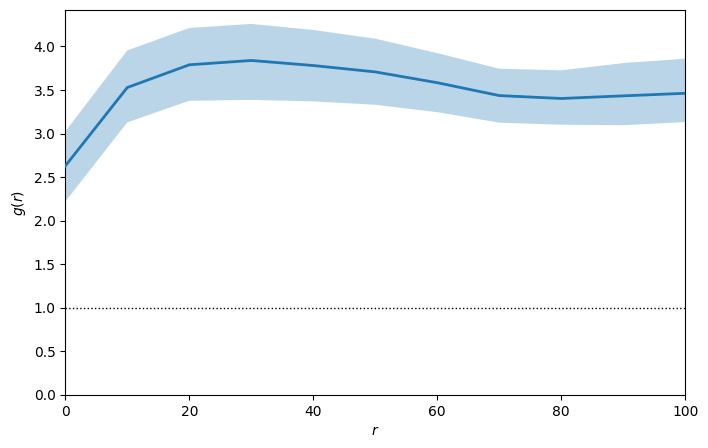

In [68]:
r, PCF, confidence_intervals = ms.spatial_statistics.cross_pair_correlation_function(
                domain,
                ('Cell Type', POP_A),
                ('Cell Type', POP_B),
                max_R=100,
                annulus_step=10,
                annulus_width=15,
                return_confidence_interval=True,
                visualise_output=True
            )

In [105]:
# Get unique cell types from the domain's labels
celltypes = np.unique(domain.labels["Cell Type"]["labels"])
celltypes = celltypes.tolist()[:1]
celltypes

domain_name = domain.name if domain.name is not None else "Unknown Domain"

Label Cell ID has been ignored from region counts has a lot of categories (42579). To include this label, set force_high_category_counts=True.


TypeError: 'Axes' object is not subscriptable

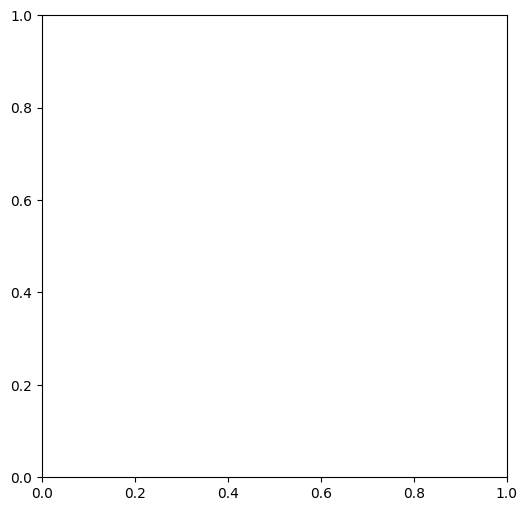

<Figure size 400x400 with 0 Axes>

In [ ]:
# Empty list to collect records for all cell type pairs
records_dict = {}
records = []

fig, axes = plt.subplots(len(celltypes), len(celltypes), figsize=(len(celltypes) * 6, len(celltypes) * 6))
fig, axes = plt.subplots(len(celltypes), len(celltypes),
                         figsize=(len(celltypes) * 6, len(celltypes) * 6))

axes = np.atleast_2d(axes)

for i in range(len(celltypes)):
    for j in range(len(celltypes)):
        r, PCF, confidence_intervals = ms.spatial_statistics.cross_pair_correlation_function(
            domain,
            ('Cell Type', celltypes[i]),
            ('Cell Type', celltypes[j]),
            max_R=100,
            annulus_step=10,
            annulus_width=15,
            return_confidence_interval=True,
            visualise_output=False
        )

        # Extract values for the dataframe
        # cPCF values
        r_vals   = r.values   if hasattr(r,   'values') else r
        pcf_vals = PCF.values if hasattr(PCF, 'values') else PCF
        n_pts    = len(r_vals)
        
        # Confidence intervals
        r_ci_vals = r
        conf_ints = confidence_intervals.values if hasattr(confidence_intervals, 'values') else confidence_intervals
        ci_low = conf_ints[0, :].astype("float32")
        ci_high = conf_ints[1, :].astype("float32")
        
        # Store cPCF values in df for this cell type pair
        df_cPCF = pd.DataFrame({
            'domain':     [domain_name] * n_pts,
            'celltype_i': [celltypes[i]] * n_pts,
            'celltype_j': [celltypes[j]] * n_pts,
            'r':          r_vals.astype('float32'),
            'PCF':        pcf_vals.astype('float32'),
        })
        
        # Store confidence interval dataframes for this cell type pair
        df_ci = pd.DataFrame({
            "domain": domain_name,
            "celltype_i": celltypes[i],
            "celltype_j": celltypes[j],
            "r_ci": r_ci_vals.astype("float32"),
            "ci_low": ci_low.astype("float32"),
            "ci_high": ci_high.astype("float32"),
        })
        
        # Add to the records list
        records.append(df_cPCF)
        
        # Store cPCF and confidence interval dataframes in the dictionary for this cell type pair
        pair_key = f"{celltypes[i]}_x_{celltypes[j]}"
        records_dict[pair_key] = {
            "cPCF": df_cPCF,
            "confidence_intervals": df_ci
        }
        
        # Save the plot for this cell type pair
        plt.figure(figsize=(4, 4))
        ax = axes[i, j]
        ax.plot(r, PCF, label='PCF', color="#5c91c6")
        ax.set_title(f"{celltypes[i]} × {celltypes[j]}", fontsize=10)
        ax.set_xlabel("Distance (r)")
        ax.set_ylabel("PCF")
        ax.legend()
        ax.grid(False)
        plt.tight_layout()
        
# Save plots for all cell type pairs
fig.tight_layout()
fig.savefig(f"/Users/sarapatti/Desktop/cross_PCF_{domain_name}.png", dpi=300)
plt.close(fig)

In [ ]:
# Save the combined dataframe for all cell type pairs
df = pd.concat(records, ignore_index=True)
for col in ['domain', 'celltype_i', 'celltype_j']:
    df[col] = df[col].astype('category')
# df.to_parquet(data_dir / f"{domain_name}_cross_PCF.parquet", index=False)
# logger.info(f"[{domain_name}] Saved: {domain_name}_cross_PCF.parquet")

,domain,celltype_i,celltype_j,r,PCF
0,IPF_RBH_16,AT1 cells,AT2 cells,0.0,3.796562
1,IPF_RBH_16,AT1 cells,AT2 cells,10.0,4.199353
2,IPF_RBH_16,AT1 cells,AT2 cells,20.0,4.039262
3,IPF_RBH_16,AT1 cells,AT2 cells,30.0,3.770358
4,IPF_RBH_16,AT1 cells,AT2 cells,40.0,3.516775
5,IPF_RBH_16,AT1 cells,AT2 cells,50.0,3.406880
6,IPF_RBH_16,AT1 cells,AT2 cells,60.0,3.334440
7,IPF_RBH_16,AT1 cells,AT2 cells,70.0,3.388480
8,IPF_RBH_16,AT1 cells,AT2 cells,80.0,3.347880
9,IPF_RBH_16,AT1 cells,AT2 cells,90.0,3.203701


# GROUP

In [16]:
# Load metadata
meta_df = pd.read_csv(base_path / "data" / "meta" / "STx_meta_analysis_only_cleaned.csv", index_col=0)

# convert to dict of dicts
metadata_dict = meta_df.to_dict(orient="index")

In [29]:
parts = sorted(data_dir.glob("*_cross_PCF.parquet"))
print(f"Found {len(parts)} patient Parquet files.")

df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
df["ROI"] = df["ROI"].str.rsplit("_muspan_domain", n=1).str[0]
for col in ['ROI', 'celltype_i', 'celltype_j']:
    df[col] = df[col].astype('category')

# Add all metadata to the dataframe
df.set_index("ROI", inplace=True, drop=True)

Found 49 patient Parquet files.


In [50]:
# Add metadata columns to the dataframe
df_complete = df.join(meta_df, on="ROI", how="left")

In [53]:
POP_A = "AT2 cells"
POP_B = "Airway/Alveolar macrophages"
GROUPBY = "sample_ID"

# Set saving population names
save_pop_A = (
    POP_A.replace("/", "_").replace(" ", "_").replace("+", "pos")
)
save_pop_B = (
    POP_B.replace("/", "_").replace(" ", "_").replace("+", "pos")
)

In [54]:
filter_df = df_complete[(df_complete["celltype_i"] == POP_A) & (df_complete["celltype_j"] == POP_B)]

<Axes: xlabel='r', ylabel='PCF'>

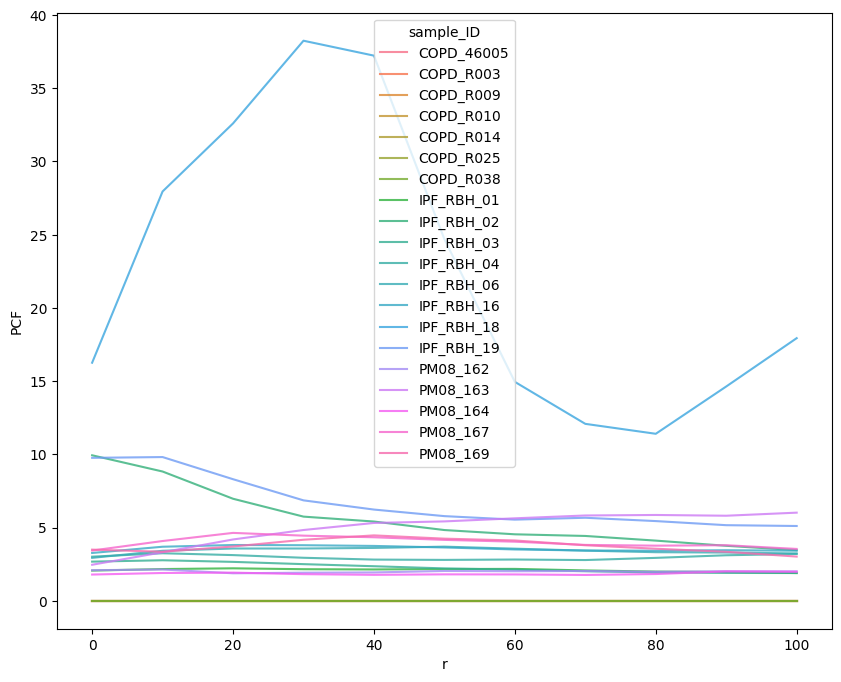

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.lineplot(
    data=filter_df,
    x="r",
    y="PCF",
    hue=GROUPBY,
    estimator=None,
    alpha=0.8,
    ax=ax,
)

# # Add per-sample confidence bands
# for sample, sub in filter_df.groupby(GROUPBY):
#     plt.fill_between(
#         sub["r"],
#         sub["ci_low"],
#         sub["ci_high"],
#         alpha=0.2,
#         color=sns.color_palette("tab10")[
#             list(filter_df["treatment"].unique()).index(
#                 sub["treatment"].iloc[0]
#             )
#         ],
#     )

# plt.title(f"{POP_A} and {POP_B} cPCF by {GROUPBY}")
# plt.ylabel("cPCF")
# plt.xlabel("Distance (µm)")


# # Mean with 95% confidence interval
# fig2, ax2 = plt.subplots(figsize=(10, 8))
# sns.lineplot(
#     data=filter_df,
#     x="r",
#     y="PCF",
#     hue=GROUPBY,
#     # Remove units and estimator=None to allow aggregation
#     errorbar=("ci", 95),  # 95% confidence interval
#     ax=ax2,
# )